In [1]:
import joblib
from collections import Counter
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import DUPLICATE_DATASETS

sns.set(context='poster')

In [2]:
svc_results, log_reg_results, random_forest_results, evaluated_datasets, baseline_times = joblib.load('results/compare_baseline_models.joblib')

database = pd.read_json('database.json').T
database.loc[:, 'nrow'] = np.minimum(10000, database['nrow'])

optuna_results, optuna_times, optuna_datasets = joblib.load('results/optuna_models.joblib')

In [3]:
FOLD_COLS = ['prauc_fold_1', 'prauc_fold_2', 'prauc_fold_3', 'prauc_fold_4']

svc_df = pd.DataFrame(svc_results, columns=FOLD_COLS, index=evaluated_datasets)
svc_df['model'] = 'SVC'
log_reg_df = pd.DataFrame(log_reg_results, columns=FOLD_COLS, index=evaluated_datasets)
log_reg_df['model'] = 'Logistic Regression'
random_forest_df = pd.DataFrame(random_forest_results, columns=FOLD_COLS, index=evaluated_datasets)
random_forest_df['model'] = 'Random Forest'

OPTUNA_MODEL_LABELS = {
    'svc':            'SVC (GridSearch)',
    'logreg':         'Logistic Regression (GridSearch)',
    'random_forest':  'Random Forest (Optuna)',
    'xgboost':        'XGBoost (Optuna)',
    'sgd':            'SGD (Optuna)',
    'catboost':       'CatBoost (Optuna)',
    'lgbm':           'LightGBM (Optuna)',
    'lgbm_linear':    'LightGBM Linear (Optuna)',
    'hgb':            'HistGradientBoosting (Optuna)',
    'resnet':         'ResNet (Optuna)',
    'tabnet':         'TabNet (Optuna)',
    'tabpfn3':        'TabPFN-3 (GridSearch)',
    'tabpfn35':       'TabPFN-3.5 (GridSearch)',
    'tabpfn35fast':   'TabPFN-3.5-fast (GridSearch)',
    'tabicl':         'TabICL (GridSearch)',
    'tabfm':          'TabFM (zero-shot)',
}
missing = [k for k in OPTUNA_MODEL_LABELS if k not in optuna_results]
if missing:
    print(f'WARNING: absent from the aggregate, not plotted: {missing}')

optuna_dfs = []
for model_key, label in OPTUNA_MODEL_LABELS.items():
    if model_key not in optuna_results:
        continue
    df = pd.DataFrame(optuna_results[model_key], columns=FOLD_COLS, index=optuna_datasets)
    df['model'] = label
    optuna_dfs.append(df)

In [4]:
SPLIT_COLS = ['prauc_split_1', 'prauc_split_2', 'prauc_split_3', 'prauc_split_4']

results_df = pd.concat(
    [svc_df, log_reg_df, random_forest_df] + optuna_dfs,
    axis=0
)
results_df.columns = SPLIT_COLS + ['model']
results_df['dataset'] = results_df.index

for col in database.columns:
    results_df[col] = results_df.index.map(database[col]).to_numpy()

results_df['mean_prauc'] = results_df[SPLIT_COLS].mean(axis=1)
results_df['min_prauc']  = results_df[SPLIT_COLS].min(axis=1)
results_df['max_prauc']  = results_df[SPLIT_COLS].max(axis=1)
results_df['std_prauc']  = results_df[SPLIT_COLS].std(axis=1)

# Per-fold delta relative to RF baseline
rf_baseline = pd.DataFrame(
    random_forest_results,
    columns=SPLIT_COLS,
    index=evaluated_datasets,
)
RF_COLS    = ['rf_prauc_split_1', 'rf_prauc_split_2', 'rf_prauc_split_3', 'rf_prauc_split_4']
DELTA_COLS = ['delta_split_1', 'delta_split_2', 'delta_split_3', 'delta_split_4']
for rf_col, split_col in zip(RF_COLS, SPLIT_COLS):
    results_df[rf_col] = results_df.index.map(rf_baseline[split_col]).to_numpy()
for delta_col, split_col, rf_col in zip(DELTA_COLS, SPLIT_COLS, RF_COLS):
    results_df[delta_col] = results_df[split_col] - results_df[rf_col]

results_df['mean_delta'] = results_df[DELTA_COLS].mean(axis=1)
results_df['std_delta']  = results_df[DELTA_COLS].std(axis=1)

results_df = results_df.reset_index(drop=True)

In [5]:
# exclude datasets where every algorithm does really well
results_df = results_df.groupby('dataset').filter(lambda x: x['mean_prauc'].min() < 0.99)

In [6]:
# The UCI++ variants that score identically across the board. Same list the
# runs skip, so the figures and the compute agree on the population.
results_df = results_df[~results_df['dataset'].isin(DUPLICATE_DATASETS)].reset_index(drop=True)
evaluated_datasets = set(results_df['dataset'])

In [7]:
winning_algorithms = []
for dataset in evaluated_datasets:
    df_sub = results_df[results_df['dataset'] == dataset]
    highest_prauc = df_sub['mean_prauc'].max()
    winning_algorithms.extend(df_sub.loc[df_sub['mean_prauc'] >= highest_prauc * 0.995, 'model'])
print('Datasets each algorithm does best on (a model unscored on a dataset can '
      'never win it — read with the coverage column below):')
pprint(Counter(winning_algorithms))

losing_algorithms = []
for dataset in evaluated_datasets:
    df_sub = results_df[results_df['dataset'] == dataset]
    worst_prauc = df_sub['mean_prauc'].min()
    losing_algorithms.extend(df_sub.loc[df_sub['mean_prauc'] <= worst_prauc * 1.005, 'model'])
print('\nDatasets each algorithm does worst on:')
pprint(Counter(losing_algorithms))

# Coverage differs by model and pandas skips NaN, so each model is averaged
# over its own subset. n makes that visible.
print('\nDelta PR AUC vs RF baseline, each model over its own coverage:')
print(results_df.groupby('model')['mean_delta']
      .agg(n='count', mean='mean', median='median')
      .sort_values('mean', ascending=False).to_string())

# Paired view over identical datasets. Models below MIN_COVERAGE are dropped
# rather than allowed to shrink the intersection.
MIN_COVERAGE = 0.9
pivot_delta = results_df.pivot_table(index='dataset', columns='model', values='mean_delta')
paired_models = pivot_delta.columns[pivot_delta.notna().mean() >= MIN_COVERAGE]
paired = pivot_delta[paired_models].dropna()
print(f'\nComplete-case delta vs RF ({len(paired)} datasets, {len(paired_models)} '
      f'models at >={MIN_COVERAGE:.0%} coverage):')
print(paired.mean().sort_values(ascending=False).to_string())

# Pairwise win/loss matrix
models_ordered = results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).index.tolist()
pivot = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc')
TOL = 0.005
win_matrix = pd.DataFrame(index=models_ordered, columns=models_ordered, dtype=float)
for a in models_ordered:
    for b in models_ordered:
        if a == b:
            win_matrix.loc[a, b] = np.nan
        else:
            diff = pivot[a] - pivot[b]
            win_matrix.loc[a, b] = (diff.dropna() > TOL).sum()
print('\nPairwise wins (row beats col on N datasets, each pair on its own overlap):')
print(win_matrix.to_string())

# Complete cases and method='min': fractional ranks from method='average' match
# no integer column and drop out of the distribution silently.
rank_pivot = pivot[paired_models].dropna().rank(axis=1, ascending=False, method='min')
rank_dist = pd.DataFrame(index=paired_models)
for r in range(1, len(paired_models) + 1):
    rank_dist[f'rank_{r}'] = (rank_pivot == r).sum()
rank_dist['mean_rank'] = rank_pivot.mean()
print(f'\nRank distribution over {len(rank_pivot)} complete-case datasets:')
print(rank_dist.sort_values('mean_rank').to_string())

Datasets each algorithm does best on (a model unscored on a dataset can never win it — read with the coverage column below):
Counter({'TabPFN-3.5 (GridSearch)': 87,
         'TabPFN-3.5-fast (GridSearch)': 74,
         'TabFM (zero-shot)': 71,
         'TabICL (GridSearch)': 70,
         'TabPFN-3 (GridSearch)': 65,
         'CatBoost (Optuna)': 41,
         'Random Forest': 35,
         'SVC (GridSearch)': 34,
         'LightGBM (Optuna)': 34,
         'LightGBM Linear (Optuna)': 34,
         'XGBoost (Optuna)': 33,
         'Random Forest (Optuna)': 32,
         'ResNet (Optuna)': 32,
         'SVC': 30,
         'HistGradientBoosting (Optuna)': 28,
         'Logistic Regression': 27,
         'Logistic Regression (GridSearch)': 20,
         'TabNet (Optuna)': 17,
         'SGD (Optuna)': 14})

Datasets each algorithm does worst on:
Counter({'TabNet (Optuna)': 71,
         'SGD (Optuna)': 31,
         'SVC': 22,
         'Logistic Regression (GridSearch)': 21,
         'Logistic Regr

In [8]:
flag = set(database[database.nrow < 250].index)

print('Average delta vs RF baseline when nrow < 250')
print(results_df[results_df['dataset'].isin(flag)].groupby('model')['mean_delta'].mean().sort_values(ascending=False))
print('\nMedian delta vs RF baseline when nrow < 250')
print(results_df[results_df['dataset'].isin(flag)].groupby('model')['mean_delta'].median().sort_values(ascending=False))

Average delta vs RF baseline when nrow < 250
model
TabICL (GridSearch)                 0.033152
TabFM (zero-shot)                   0.030974
TabPFN-3.5 (GridSearch)             0.029814
TabPFN-3.5-fast (GridSearch)        0.029746
TabPFN-3 (GridSearch)               0.028513
CatBoost (Optuna)                   0.013776
Random Forest (Optuna)              0.008966
SVC (GridSearch)                    0.002065
Random Forest                       0.000000
XGBoost (Optuna)                   -0.001885
LightGBM Linear (Optuna)           -0.002161
HistGradientBoosting (Optuna)      -0.005220
LightGBM (Optuna)                  -0.005658
ResNet (Optuna)                    -0.012415
SGD (Optuna)                       -0.058552
Logistic Regression (GridSearch)   -0.062304
SVC                                -0.069379
Logistic Regression                -0.080269
TabNet (Optuna)                    -0.088868
Name: mean_delta, dtype: float64

Median delta vs RF baseline when nrow < 250
model
TabPFN-3.5

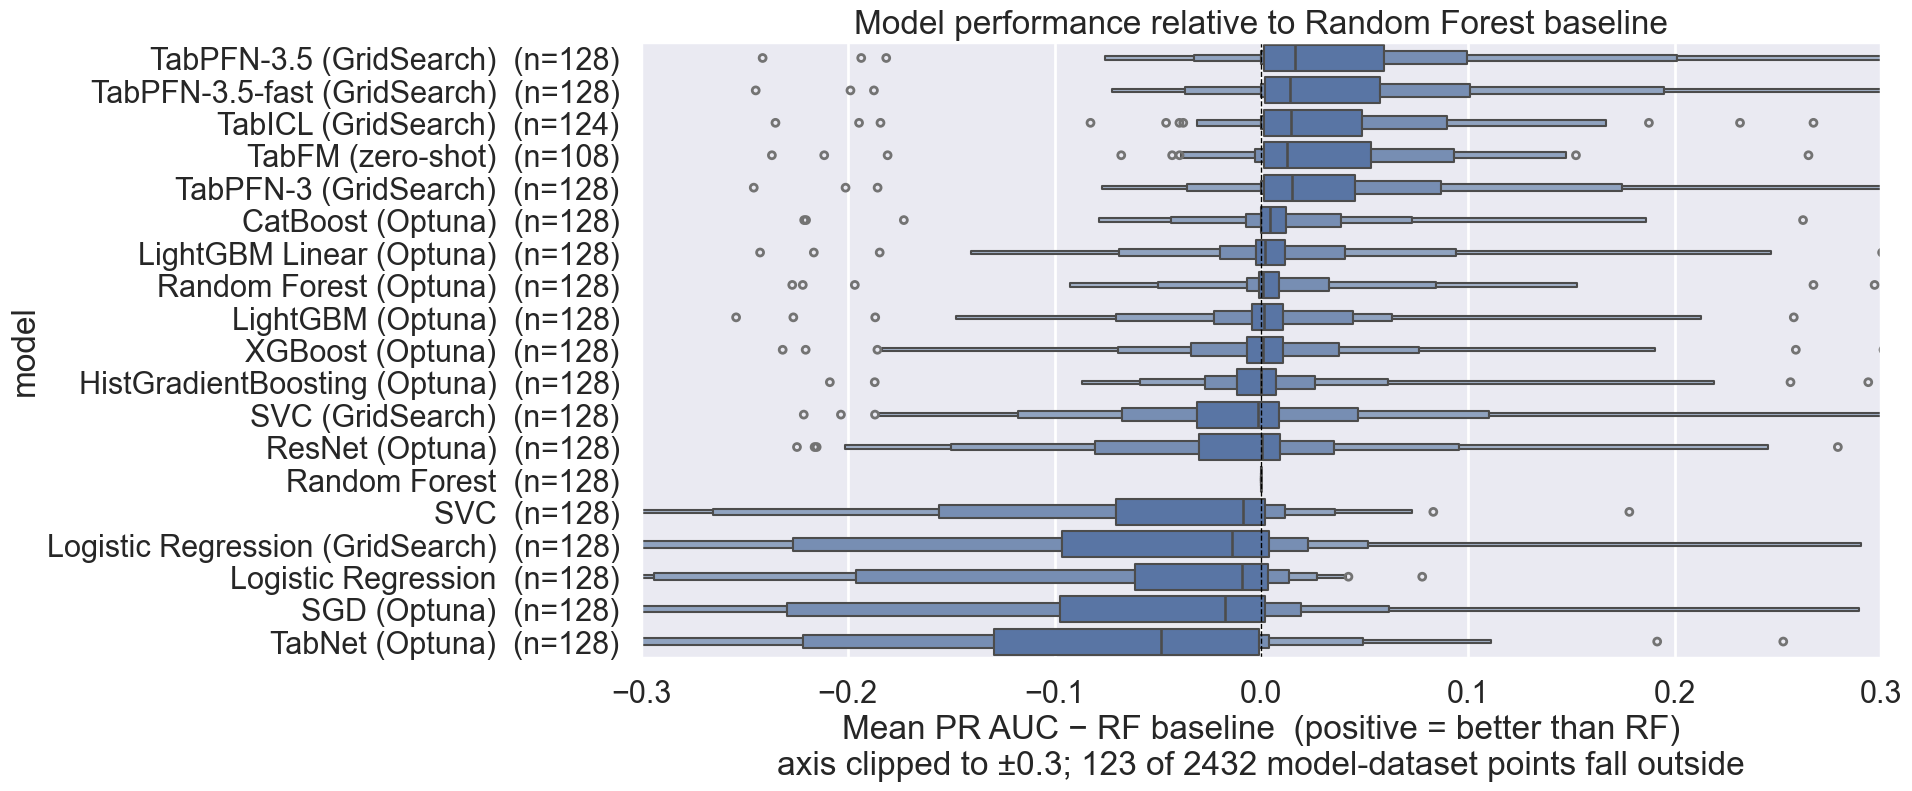

In [9]:
# distributions of delta PR AUC vs RF baseline.
# n is per-model coverage — the boxes are not drawn over the same datasets.
counts = results_df.groupby('model')['mean_delta'].count()
order = results_df.groupby('model')['mean_delta'].mean().sort_values(ascending=False).index
fig, ax = plt.subplots()
fig.set_size_inches(16, 8)
sns.boxenplot(data=results_df, x='mean_delta', y='model', order=order, ax=ax)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
# Clip the axis: a 4% tail would squeeze every box into an unreadable strip.
# What falls outside is annotated rather than hidden.
XLIM = 0.3
ax.set_xlim(-XLIM, XLIM)
n_out = (results_df['mean_delta'].abs() > XLIM).sum()
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f'{m}  (n={counts[m]})' for m in order])
ax.set_xlabel(f'Mean PR AUC − RF baseline  (positive = better than RF)'
              f'\naxis clipped to ±{XLIM}; {n_out} of {len(results_df)} '
              f'model-dataset points fall outside')
ax.set_title('Model performance relative to Random Forest baseline')
fig.savefig('figures/model_performance_vs_rf.png', dpi=150, bbox_inches='tight')

Text(127.16420654296876, 0.5, 'Mean PR AUC − RF baseline')

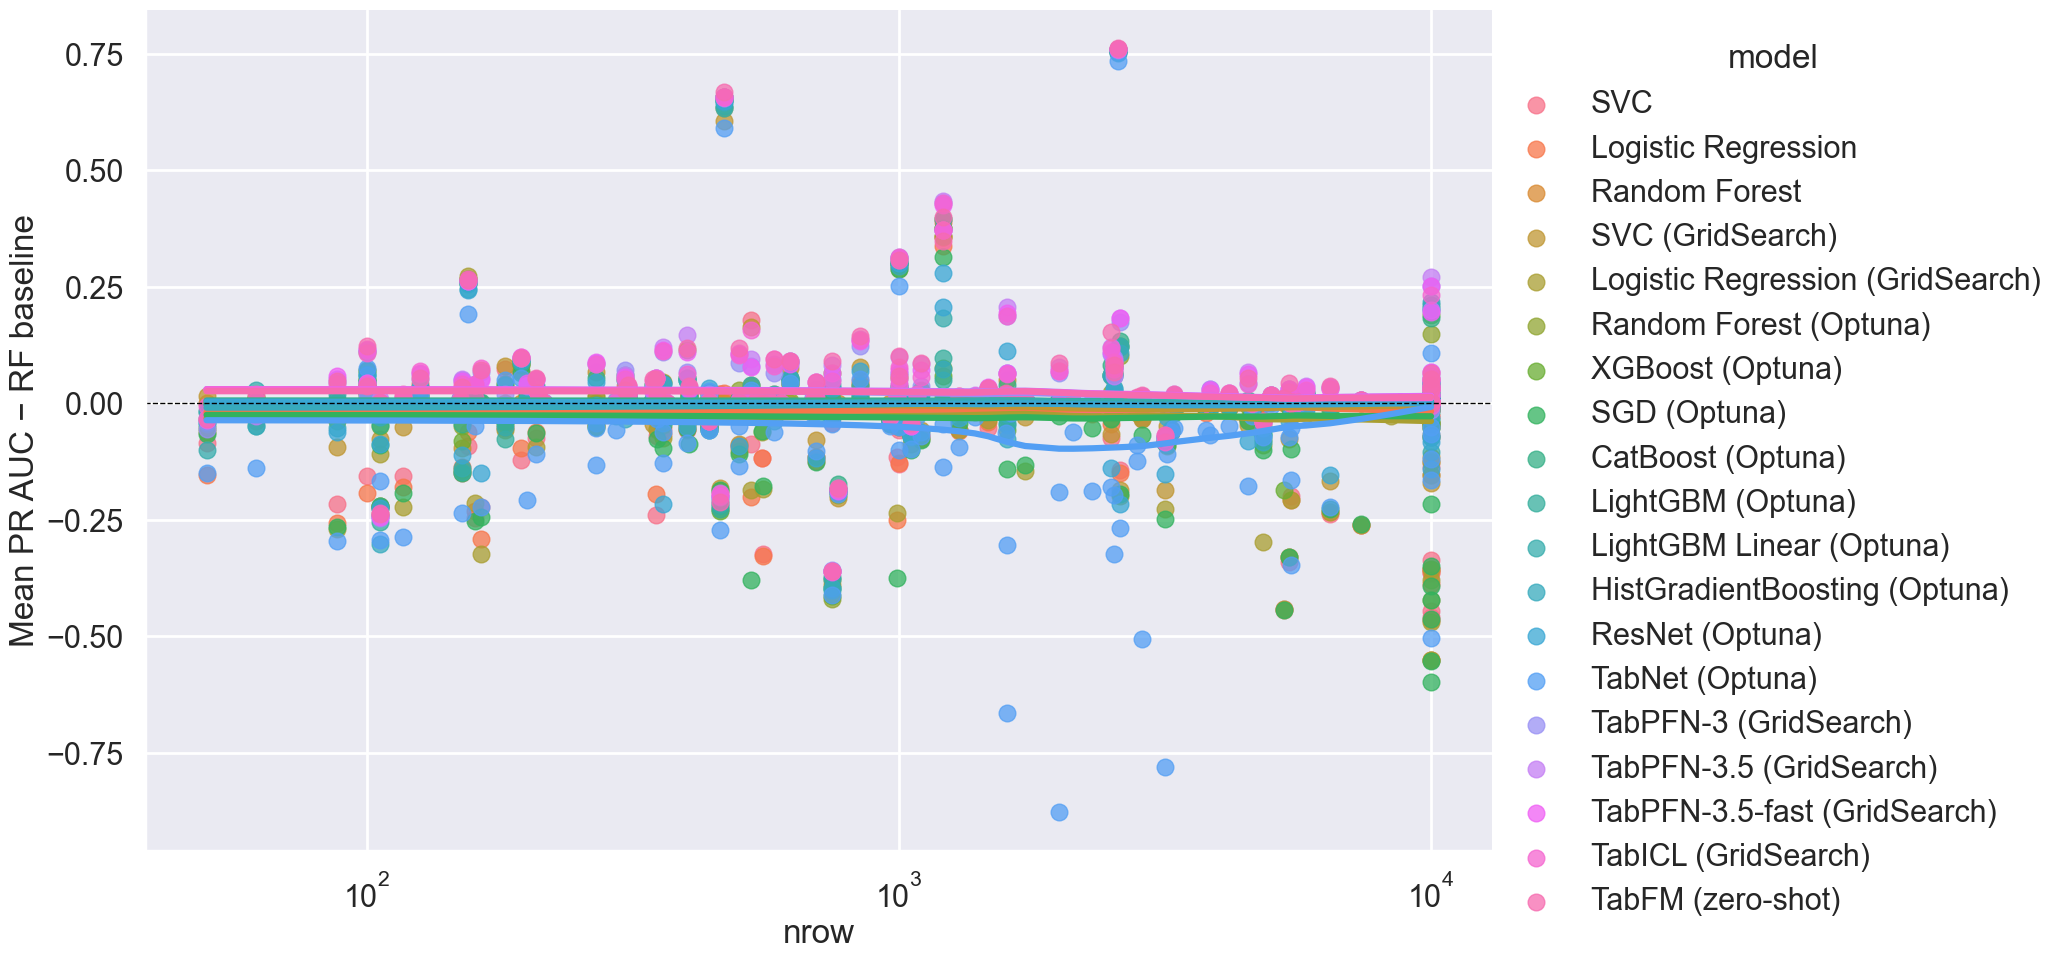

In [10]:
# delta PR AUC vs number of samples
g = sns.lmplot(
    data=results_df,
    x='nrow', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.75}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_ylabel('Mean PR AUC − RF baseline')

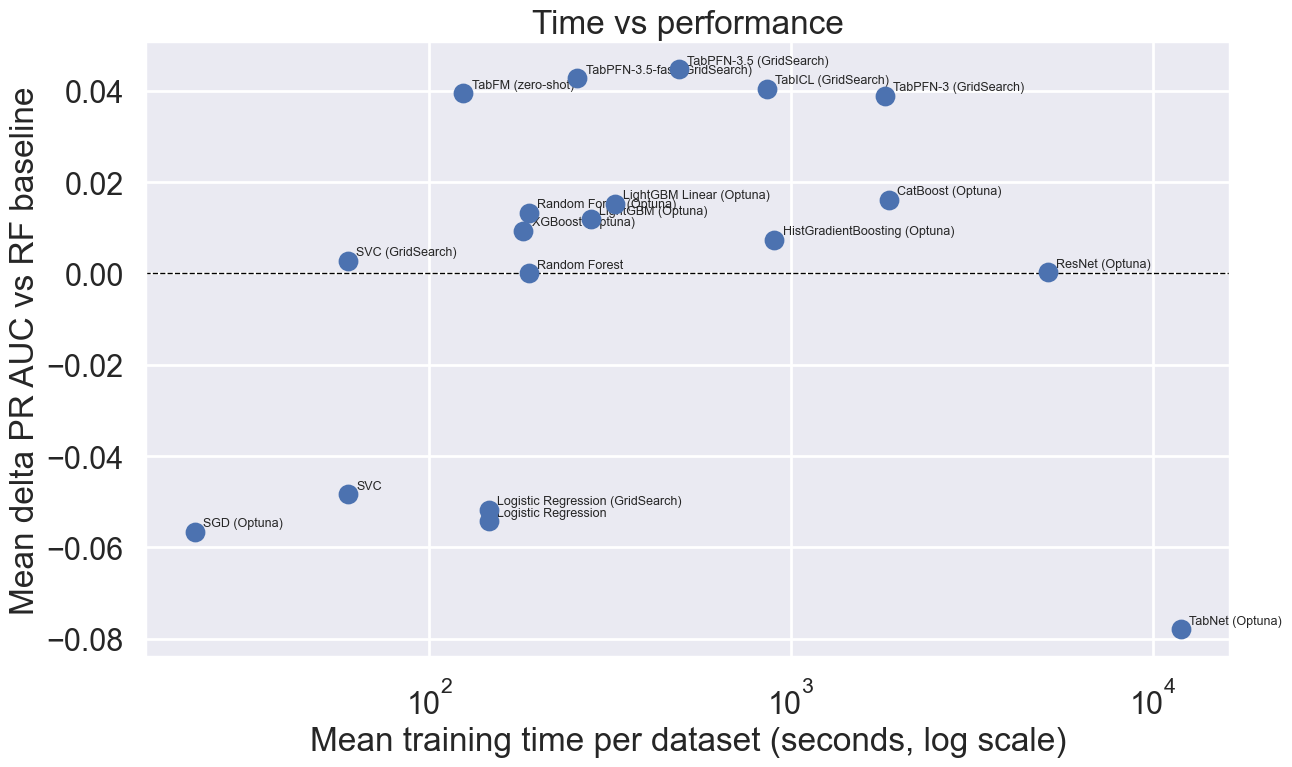

In [11]:
# Time-performance tradeoff
time_lookup = {}
for model_key, label in OPTUNA_MODEL_LABELS.items():
    if model_key in optuna_times and len(optuna_times[model_key]) > 0:
        time_lookup[label] = np.nanmean(optuna_times[model_key])

# optuna_times as proxy: baseline_times is the total for all 3 models, not per-model.
time_lookup['SVC'] = np.nanmean(optuna_times['svc'])
time_lookup['Logistic Regression'] = np.nanmean(optuna_times['logreg'])
time_lookup['Random Forest'] = np.nanmean(optuna_times['random_forest'])

model_delta_mean = results_df.groupby('model')['mean_delta'].mean()
time_rows = []
for m, t in time_lookup.items():
    d = model_delta_mean.get(m, np.nan)
    time_rows.append({'model': m, 'mean_time_sec': t, 'mean_delta': d})
time_df = pd.DataFrame(time_rows).dropna()

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(time_df['mean_time_sec'], time_df['mean_delta'], s=150, zorder=5)
for _, row in time_df.iterrows():
    ax.annotate(row['model'], (row['mean_time_sec'], row['mean_delta']),
                fontsize=9, xytext=(6, 4), textcoords='offset points')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Mean training time per dataset (seconds, log scale)')
ax.set_ylabel('Mean delta PR AUC vs RF baseline')
ax.set_title('Time vs performance')
fig.savefig('figures/time_performance_tradeoff.png', dpi=150, bbox_inches='tight')

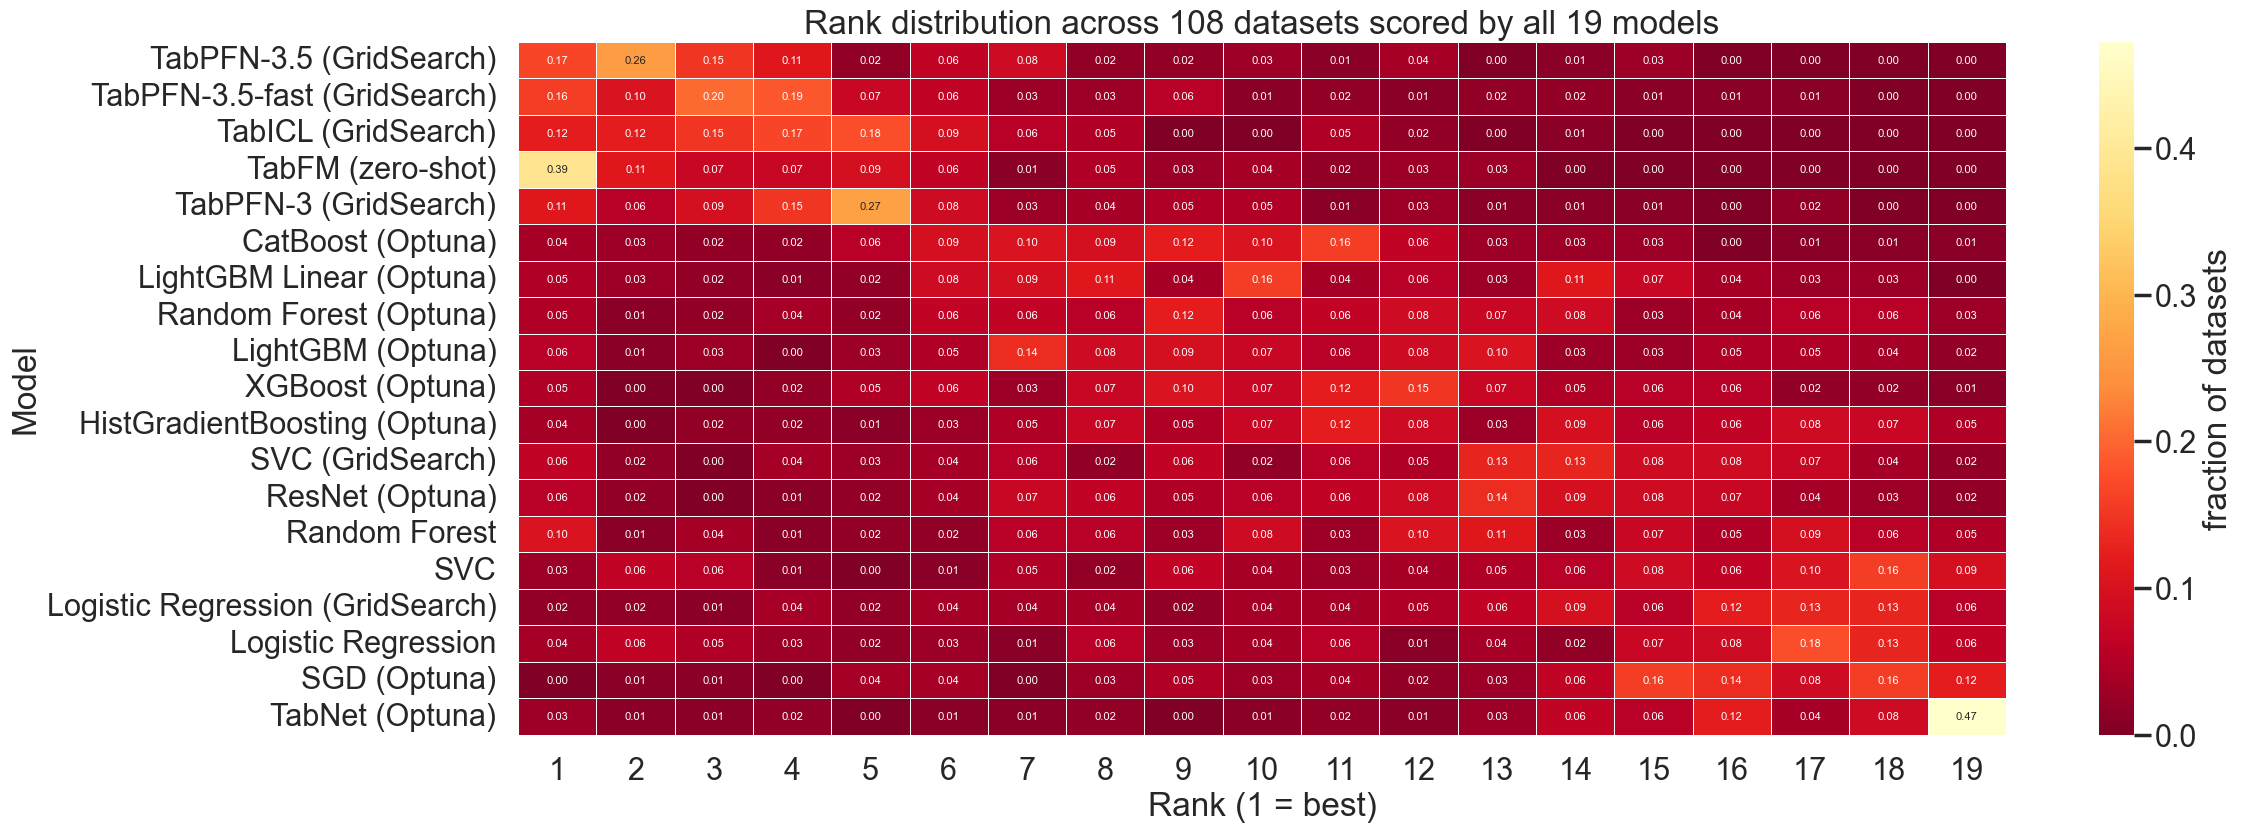

In [12]:
# Rank heatmap: fraction of datasets each model is rank k.
# Complete cases only: ranks compare only across identical datasets.
pivot_full = results_df.pivot_table(index='dataset', columns='model', values='mean_prauc').dropna()
models_by_rank = (results_df.groupby('model')['mean_delta'].mean()
                  .sort_values(ascending=False).index.tolist())
rank_pivot_full = pivot_full[models_by_rank].rank(axis=1, ascending=False, method='min')
n_ds = len(rank_pivot_full)

rank_frac = pd.DataFrame(index=models_by_rank)
for r in range(1, len(models_by_rank) + 1):
    rank_frac[r] = (rank_pivot_full == r).sum() / n_ds
assert np.allclose(rank_frac.sum(axis=1), 1.0), 'each row must be a distribution'

fig, ax = plt.subplots(figsize=(24, 9))
sns.heatmap(rank_frac, annot=True, fmt='.2f', cmap='YlOrRd_r', ax=ax,
            annot_kws={'size': 8}, linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'fraction of datasets'})
ax.set_xlabel('Rank (1 = best)')
ax.set_ylabel('Model')
ax.set_title(f'Rank distribution across {n_ds} datasets scored by all {len(models_by_rank)} models')
fig.savefig('figures/rank_distribution.png', dpi=150, bbox_inches='tight')

Text(120.9530932617187, 0.5, 'Std of delta PR AUC across folds')

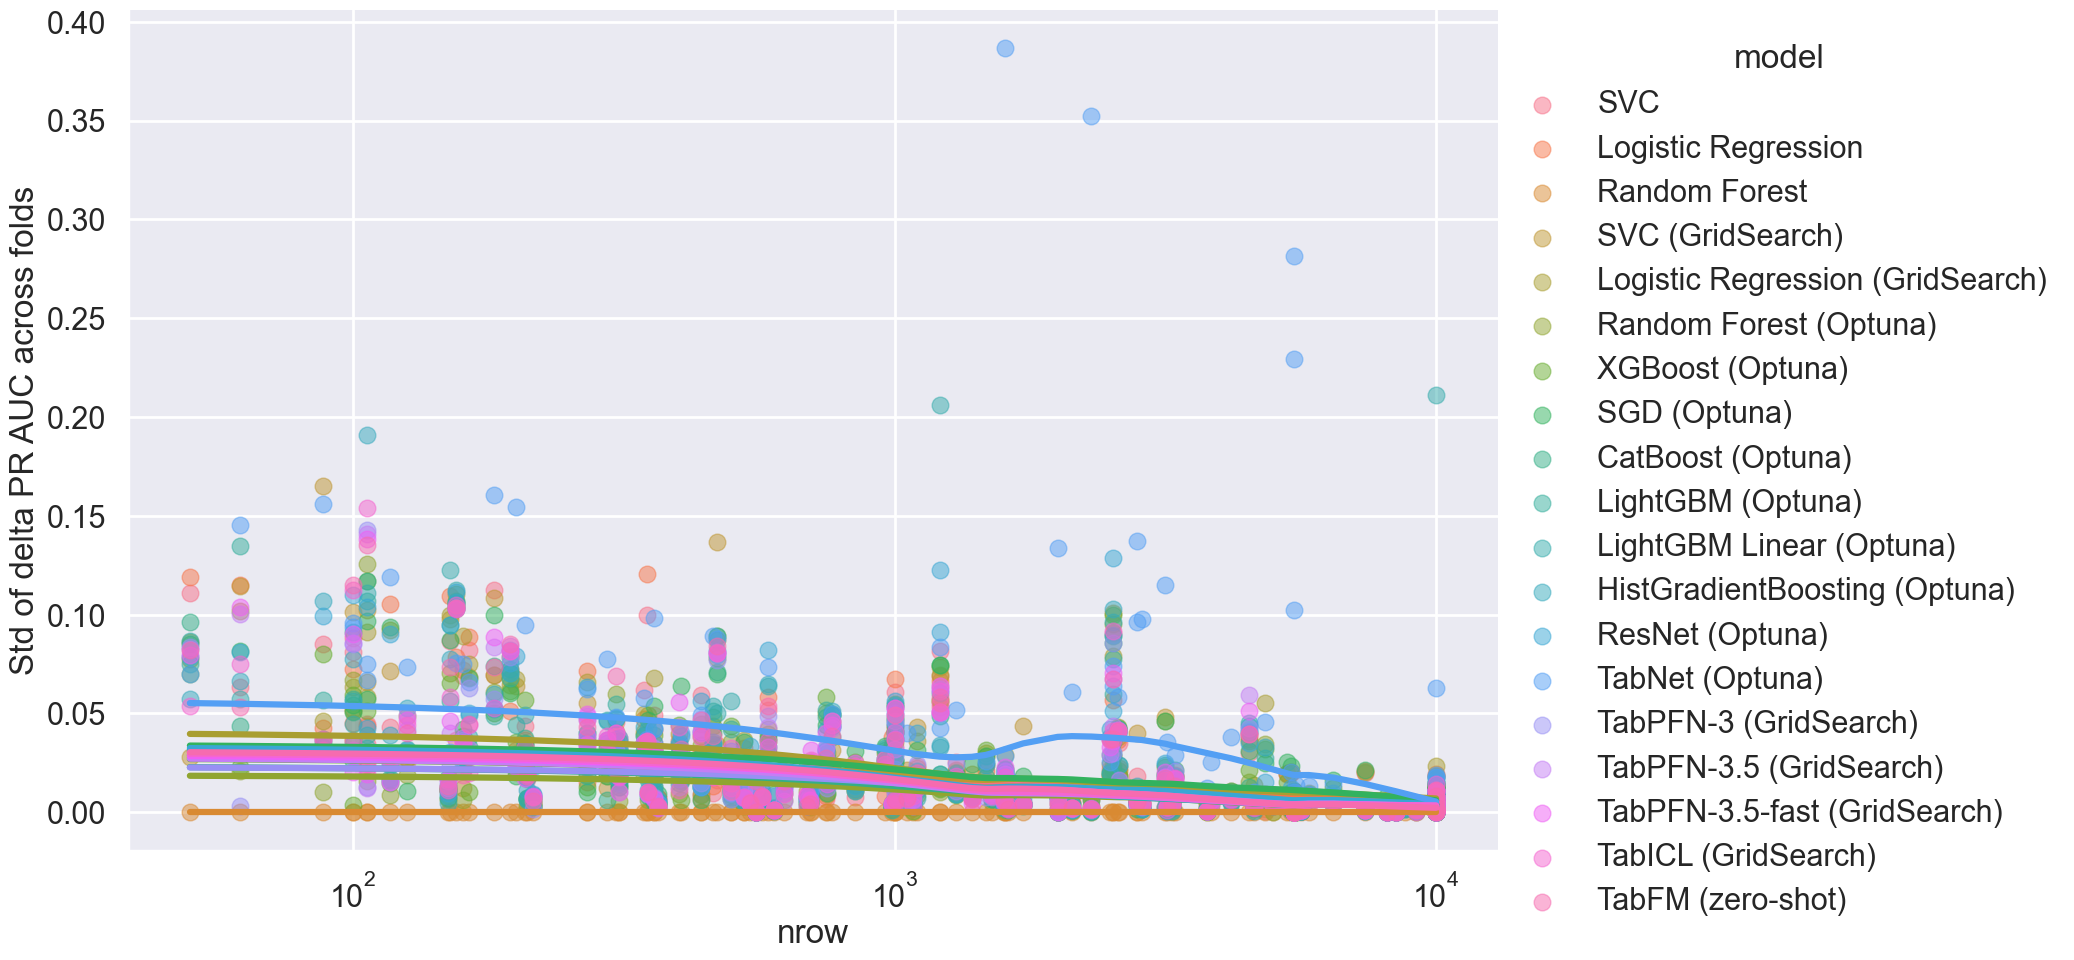

In [13]:
# variability of delta vs number of samples
g = sns.lmplot(
    data=results_df,
    x='nrow', y='std_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.set_ylabel('Std of delta PR AUC across folds')

Text(127.16420654296876, 0.5, 'Mean delta PR AUC vs RF baseline')

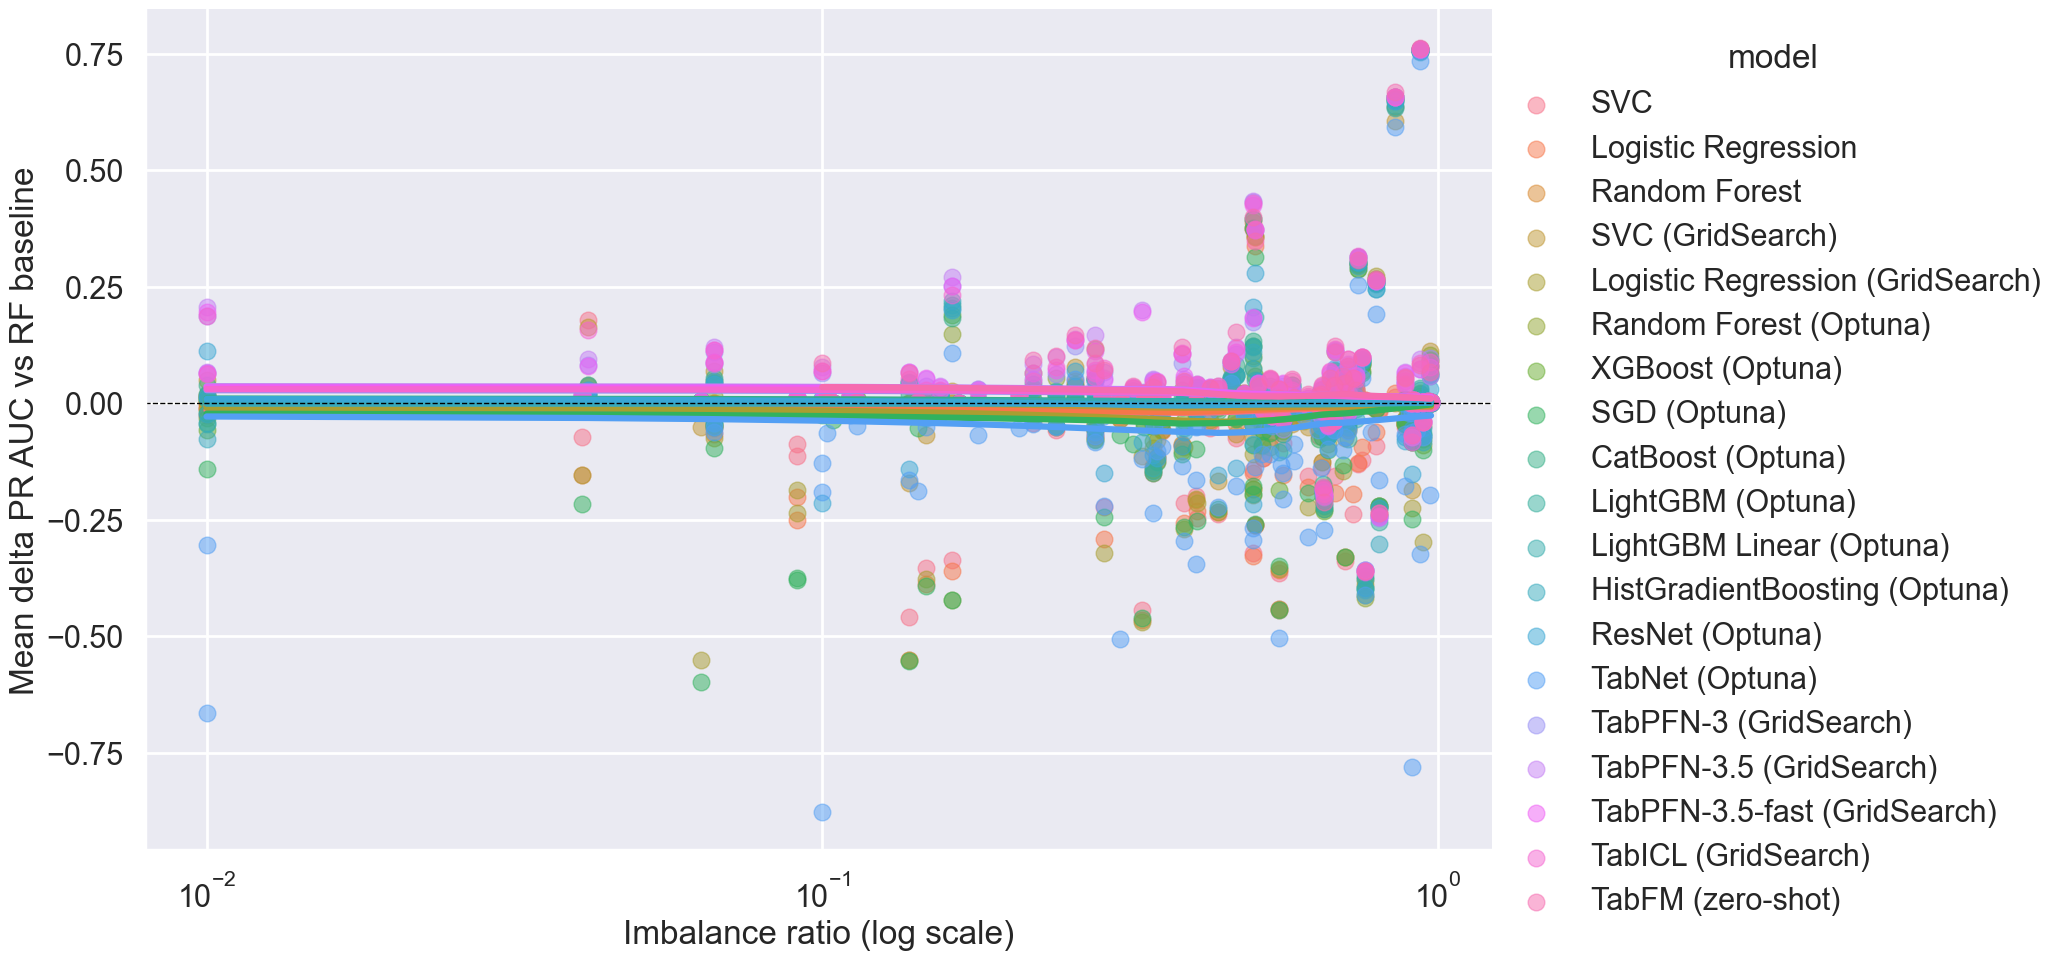

In [14]:
# delta PR AUC vs imbalance ratio
g = sns.lmplot(
    data=results_df,
    x='ir', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_xlabel('Imbalance ratio (log scale)')
g.ax.set_ylabel('Mean delta PR AUC vs RF baseline')

Text(127.16420654296876, 0.5, 'Mean delta PR AUC vs RF baseline')

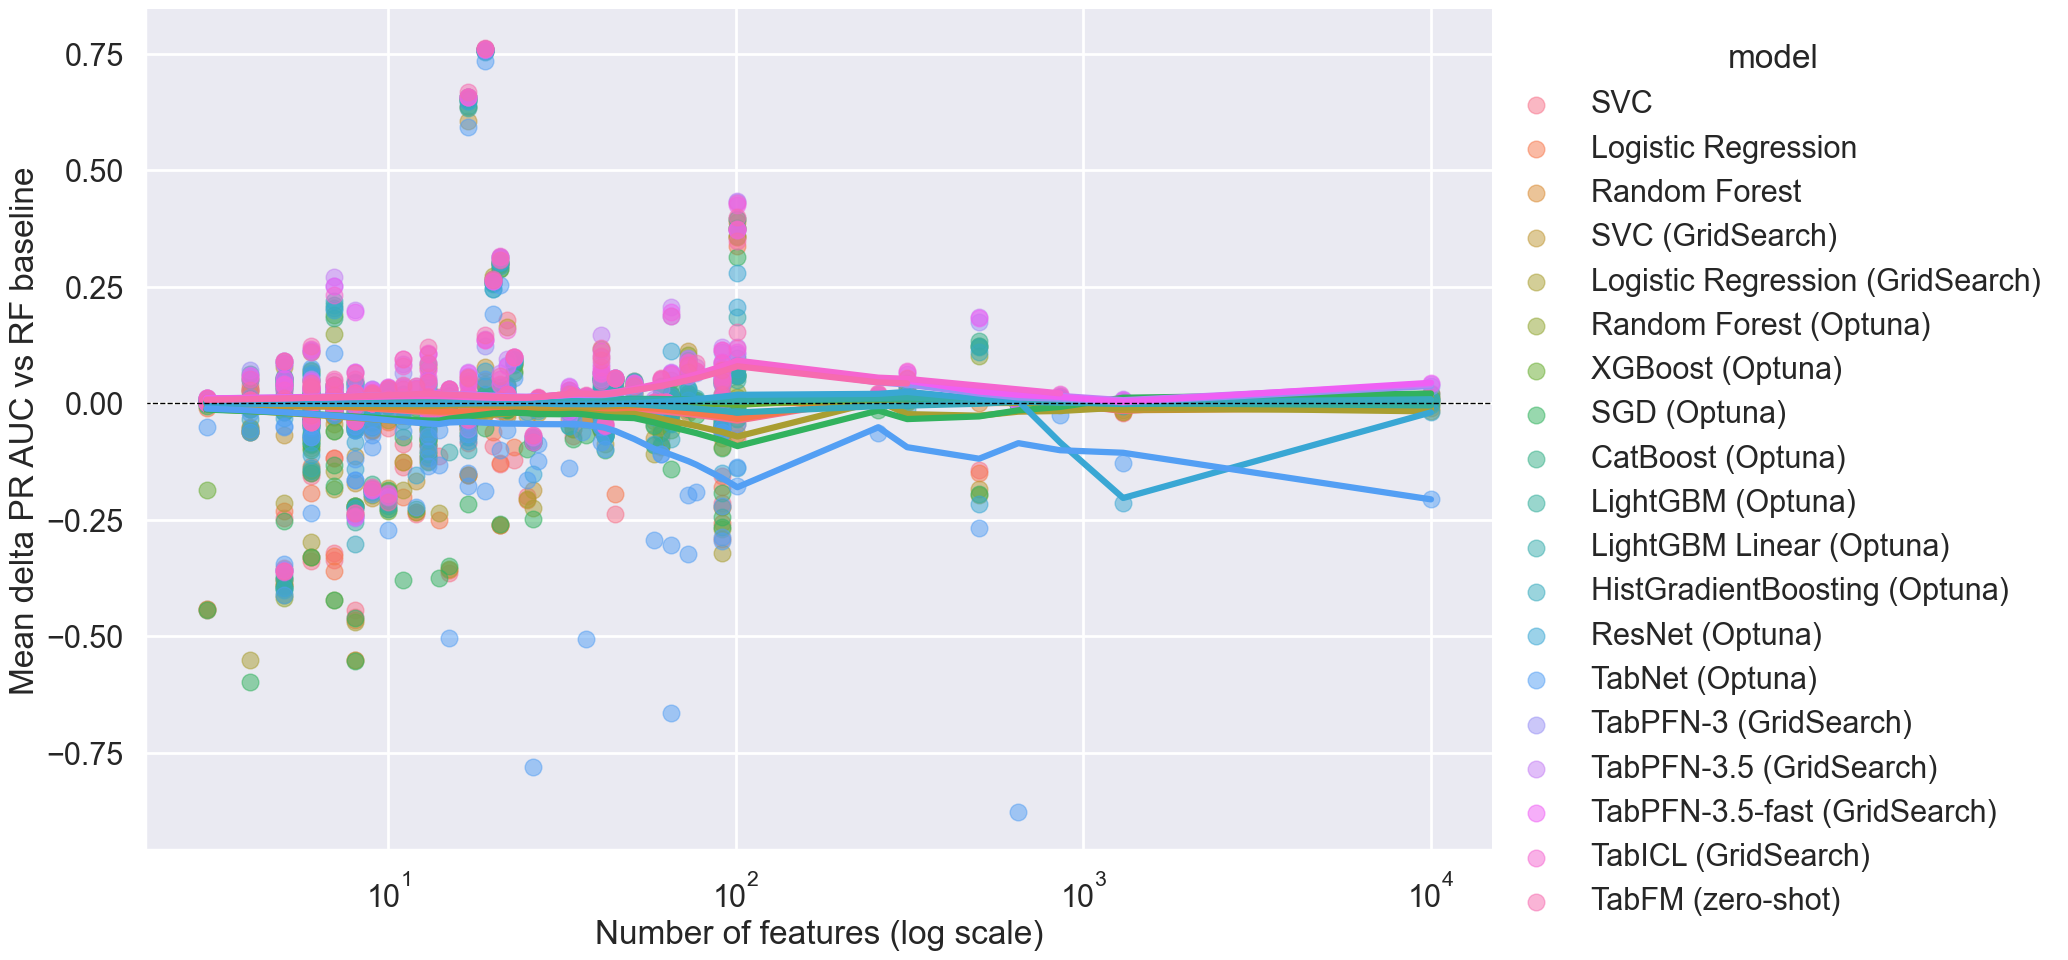

In [15]:
# delta PR AUC vs number of features
g = sns.lmplot(
    data=results_df,
    x='ncol', y='mean_delta',
    hue='model',
    lowess=True,
    height=10,
    aspect=1.6,
    scatter_kws={'alpha': 0.5}
)
g.set(xscale='log')
g.ax.axhline(0, color='black', linestyle='--', linewidth=1)
g.ax.set_xlabel('Number of features (log scale)')
g.ax.set_ylabel('Mean delta PR AUC vs RF baseline')

In [16]:
# datasets with the biggest gap between the best and second-best model.
# dropna() first: np.sort puts NaN last, so an unscored model would fill the
# printed tail with NaN.
def top2_gap(x):
    top2 = x.dropna().nlargest(2)
    return top2.iloc[0] - top2.iloc[1] if len(top2) == 2 else np.nan

results_df.groupby('dataset')['mean_prauc'].apply(top2_gap).nlargest(10)

dataset
autoUniv-au4-2500             0.031116
autoUniv-au6-cd1-400          0.027280
kr-vs-k                       0.018217
glioma16                      0.015368
mammographic-mass             0.015263
meta-data                     0.014107
appendicitis                  0.013855
pima-indians-diabetes         0.012531
statlog-heart                 0.012353
plant-species-leaves-shape    0.012255
Name: mean_prauc, dtype: float64